Data Loading and inital inspection

This Python notebook contains exploratory data analysis performed on the ISIC 2020 dataset. This analysis was carried out to better understand, inspect and clean the dataset before it was used for model training.

In [ ]:
#Name: Craig McMillan
#Student Number: 2390641
#Date: 14/03/26
#Data analysis of the ISIC 2020 dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea

#loading the three csv file for analysis
groundTruth_df = pd.read_csv("../data/raw/ISIC_2020_Training_GroundTruth.csv")
groundTruthV2_df = pd.read_csv("../data/raw/ISIC_2020_Training_GroundTruth_v2.csv")
gtDuplicates_df = pd.read_csv("../data/raw/ISIC_2020_Training_Duplicates.csv")

In [ ]:
#df_analysis function displays dimensions, first and last rows, statistics and null values of a dataframe
def df_analysis(dfName, df):
    print(dfName)
    print("Below are the dimensions of the data")
    print(df.shape)
    print()

    print("Below are the first few rows of the data")
    print(df.head())
    print()

    print("Below are the last few rows of the data")
    print(df.tail())
    print()

    print("Below is a description of the column statistics")
    print(df.describe())
    print()

    print("Below is a null value check, values are counted per column")
    print(df.isnull().sum())
    print()

    print("Below are the exact data types of each column")
    print(df.dtypes)
    print()


df_analysis("GroundTruth", groundTruth_df)
df_analysis("GroundTruth V2", groundTruthV2_df)
df_analysis("Duplicates", gtDuplicates_df)


GroundTruth
Below are the dimensions of the data
(33126, 8)

Below are the first few rows of the data
     image_name  patient_id     sex  age_approx anatom_site_general_challenge  \
0  ISIC_2637011  IP_7279968    male        45.0                     head/neck   
1  ISIC_0015719  IP_3075186  female        45.0               upper extremity   
2  ISIC_0052212  IP_2842074  female        50.0               lower extremity   
3  ISIC_0068279  IP_6890425  female        45.0                     head/neck   
4  ISIC_0074268  IP_8723313  female        55.0               upper extremity   

  diagnosis benign_malignant  target  
0   unknown           benign       0  
1   unknown           benign       0  
2     nevus           benign       0  
3   unknown           benign       0  
4   unknown           benign       0  

Below are the last few rows of the data
         image_name  patient_id   sex  age_approx  \
33121  ISIC_9999134  IP_6526534  male        50.0   
33122  ISIC_9999320  IP_365074

ground truth contains 33126 sets of data across 8 columns.
Columns are image_name, patent_id, sex, age_approx, anatom_site_general_challenge, diagnosis, benign_malignant, target
Contains null vales in columns: sex: 65, age_approx: 68, anaton_site_general_challenge: 527

ground truth v2 contains 33126 sets of data and 9 columns.
Columns are image_name, patent_id, lesion_id, sex, age_approx, anatom_site_general_challenge, diagnosis, benign_malignant, target
Extra Column is lesion_id
Contains null vales in columns: sex: 65, age_approx: 68, anaton_site_general_challenge: 527
ground truth v2 is the csv file to focus on for this analysis as it contains the lesion_id that can be linked to the duplicates list

duplicates contains 425 sets of data and 2 columns
Columns are image_name_1 and image_name_2
Contains no null values.

Assuming the duplicates csv shows image_name_1 and image_name_2 are the same image, this needs validation by checking the images.

   image_name_1  image_name_2
0  ISIC_0079038  ISIC_8521950

Below is image_name_1: ISIC_0079038


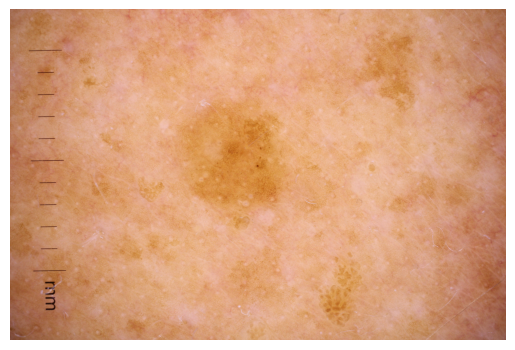

---
Below is duplicate image image_name_2: ISIC_8521950


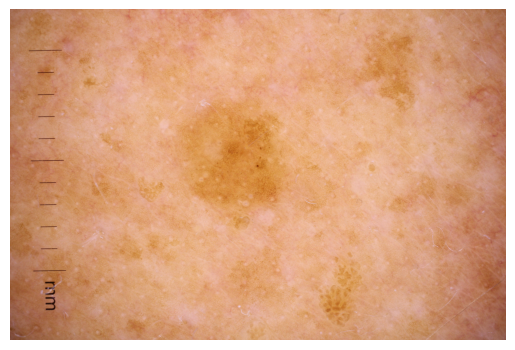

In [ ]:
#loading and displaying two images that listed as duplicates for inspection
from PIL import Image;
img1 = Image.open("../data/raw/ISIC_0079038.jpg")
plt.imshow(img1)
plt.axis("off")
print("Below is image_name_1: ISIC_0079038")
plt.show()
print("---")

img2 = Image.open("../data/raw/ISIC_8521950.jpg")
plt.imshow(img2)
plt.axis("off")
print("Below is duplicate image image_name_2: ISIC_8521950")
plt.show()

In [ ]:
#Checking the details of both duplicate images to confirm they are the same
print("See image1 details below")
print(groundTruthV2_df[groundTruthV2_df["image_name"] == "ISIC_0079038"])

print("----------------------------------------------------------------")
print("See image2 details below")
print(groundTruthV2_df[groundTruthV2_df["image_name"] == "ISIC_8521950"])

See image1 details below
      image_name  patient_id   lesion_id   sex  age_approx  \
17  ISIC_0079038  IP_5295861  IL_1642984  male        70.0   

   anatom_site_general_challenge diagnosis benign_malignant  target  
17                         torso   unknown           benign       0  
----------------------------------------------------------------
See image2 details below
         image_name  patient_id   lesion_id   sex  age_approx  \
28155  ISIC_8521950  IP_5295861  IL_1642984  male        70.0   

      anatom_site_general_challenge diagnosis benign_malignant  target  
28155                         torso   unknown           benign       0  


Displaying the data from each duplicate shows that all information is identical, apart from image_name.
Based on this, a single image from each pair can be removed from the groundTruthV2_df based on lesion_id

In [ ]:
#counting unique lesions to indentify duplicates
lesion_df = groundTruthV2_df.groupby("lesion_id")
lesion_df["image_name"].count()

lesion_id
0             1
IL_0000356    1
IL_0001060    1
IL_0001338    1
IL_0001518    1
             ..
IL_9997881    1
IL_9999213    1
IL_9999485    1
IL_9999531    1
IL_9999795    1
Name: image_name, Length: 32701, dtype: int64

Grouping by lesion_id shows 32701 sets of data.
The ground truth v2 dataset contains 33126 sets.

In [ ]:
#calculating the different between total and unique dataset entries
num1 = 33126 - 32701
print(f"Difference is {num1} sets of data")

Difference is 425 sets of data


In [ ]:
#removing the duplicate iamges from the dataset and keeping a cleaned version
duplicatesCopy_df = gtDuplicates_df.copy() 
duplicatesToRemove = set(duplicatesCopy_df["image_name_2"].dropna())
cleanedGTV2_df = groundTruthV2_df[~groundTruthV2_df["image_name"].isin(duplicatesToRemove)].copy()

print("Original groundTruthV2_df")
print(groundTruthV2_df.shape)

print("------")
print("Cleaned groundTruthV2_df")
print(cleanedGTV2_df.shape)

print("Rows removed:")
print(len(groundTruthV2_df) - len(cleanedGTV2_df))


Original groundTruthV2_df
(33126, 9)
------
Cleaned groundTruthV2_df
(32701, 9)
Rows removed:
425


In [ ]:
#performing a count to validate the removal of duplicate images
duplicatesToKeep = set(duplicatesCopy_df["image_name_1"].dropna())
accidentlyRemoved = duplicatesToKeep - set(cleanedGTV2_df["image_name"])

print("performing count to validate if correct images have been removed")
print("count of correct images removed:")
print(len(accidentlyRemoved))

performing count to validate if correct images have been removed
count of correct images removed:
0


In [ ]:
#performing futher check for duplicate images 
duplicateLesions = cleanedGTV2_df["lesion_id"].value_counts()
duplicateLesions = duplicateLesions[duplicateLesions > 1]

print("sets of data with more than 1 of the same lesion_id")
print(duplicateLesions)

duplicate_rows = cleanedGTV2_df[cleanedGTV2_df["lesion_id"].isin(duplicateLesions.index)].sort_values("lesion_id")

print(duplicate_rows)

sets of data with more than 1 of the same lesion_id
lesion_id
IL_3459064    2
IL_6648212    2
IL_2414583    2
IL_1240728    2
IL_6590948    2
IL_8087895    2
IL_1243658    2
IL_5109762    2
Name: count, dtype: int64
         image_name  patient_id   lesion_id     sex  age_approx  \
18023  ISIC_5492174  IP_4130585  IL_1240728  female        65.0   
22139  ISIC_6705662  IP_4130585  IL_1240728  female        65.0   
21259  ISIC_6450285  IP_7121757  IL_1243658  female        35.0   
21580  ISIC_6548307  IP_7121757  IL_1243658  female        35.0   
8722   ISIC_2718135  IP_5889408  IL_2414583  female        45.0   
31137  ISIC_9409255  IP_5889408  IL_2414583  female        45.0   
5156   ISIC_1642492  IP_5295861  IL_3459064    male        70.0   
29008  ISIC_8776686  IP_5295861  IL_3459064    male        70.0   
25059  ISIC_7607101  IP_5889408  IL_5109762  female        45.0   
25294  ISIC_7675261  IP_5889408  IL_5109762  female        45.0   
19960  ISIC_6063252  IP_3564160  IL_6590948  fe

duplicate lesions appear in the cleanedGTV2_df dataset, inspection of the images in necessary.
These two randomly selected sample images will be selected and displayed

       image_name  patient_id   lesion_id
5156   ISIC_1642492  IP_5295861  IL_3459064 
29008  ISIC_8776686  IP_5295861  IL_3459064

Below is dupliate image: ISIC_1642492.jpg


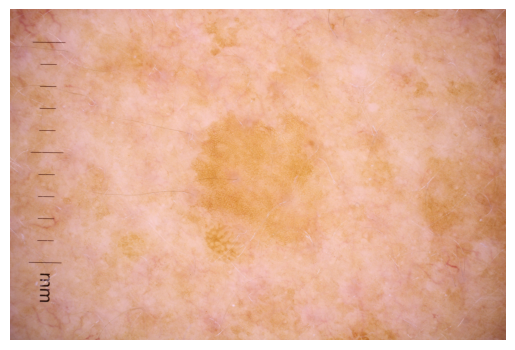

---
Below is duplicate image ISIC_8776686.jpg


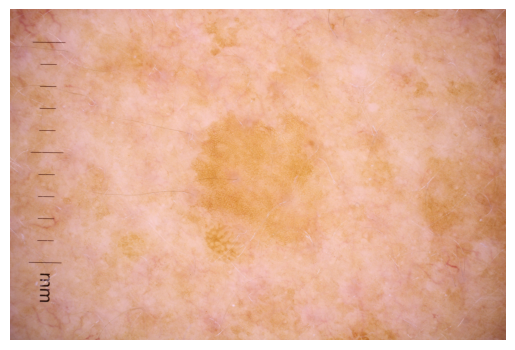

In [ ]:
#Displaying a pair of images with the same lesion_id to visually inspect for duplicates
sample1 = Image.open("../data/raw/ISIC_1642492.jpg") 
plt.imshow(sample1)
plt.axis("off")
print("Below is dupliate image: ISIC_1642492.jpg")
plt.show()
print("---")

sample2 = Image.open("../data/raw/ISIC_8776686.jpg")
plt.imshow(sample2)
plt.axis("off")
print("Below is duplicate image ISIC_8776686.jpg")
plt.show()

The two sample images selected appear to be exact duplicates. An additonal sample is required to validate this. 
The samples that will be used are:
       image_name    patient_id   lesion_id
21259  ISIC_6450285  IP_7121757  IL_1243658
21580  ISIC_6548307  IP_7121757  IL_1243658

Below is duplicate image: ISIC_6450285.jpg


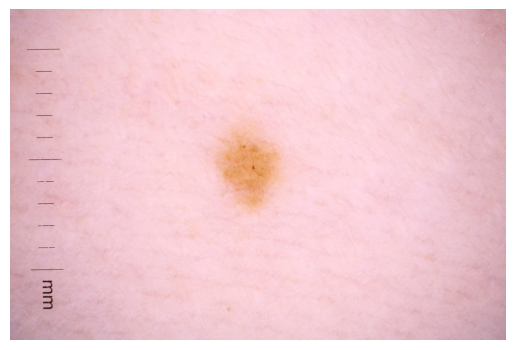

---
Below is duplicate image: ISIC_6548307.jpg


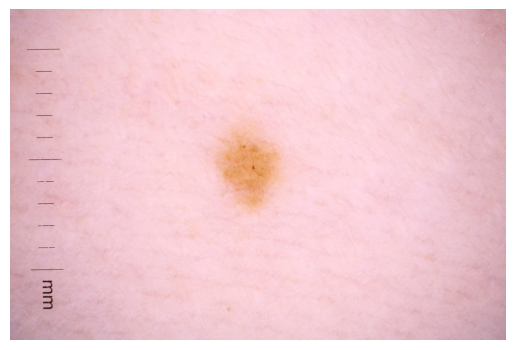

In [ ]:
#Displaying a second pair of images with the same lesion_id to visually inspect for duplicates
sample3 = Image.open("../data/raw/ISIC_6450285.jpg") 
plt.imshow(sample3)
plt.axis("off")
print("Below is duplicate image: ISIC_6450285.jpg")
plt.show()
print("---")

sample4 = Image.open("../data/raw/ISIC_6548307.jpg")
plt.imshow(sample4)
plt.axis("off")
print("Below is duplicate image: ISIC_6548307.jpg")
plt.show()

Both samples appear to include identical images and should be removed. 

In [ ]:
#Dropping the rows with duplicate lesions_ids and verifying no duplicates remain
print("Before cleaning check")
print(cleanedGTV2_df.shape)

cleanedGTV2_df = cleanedGTV2_df.drop_duplicates(subset="lesion_id", keep="first")

print("--------")
print("cleaned dataset")
print(cleanedGTV2_df.shape)
print("")
print("Remaining duplicate lesion_id")
print(cleanedGTV2_df["lesion_id"].duplicated().sum())

print("Duplicate image_name count:")
print(cleanedGTV2_df["image_name"].duplicated().sum())



Before cleaning check
(32701, 9)
--------
cleaned dataset
(32693, 9)

Remaining duplicate lesion_id
0
Duplicate image_name count:
0


Having cleaned the data for duplicates, the next step will be handling null values in order to improve data quality

In [ ]:
#Checking for null values in cleaned dataframe
print("Below is a null value check, values are counted per column")
print(cleanedGTV2_df.isnull().sum())
print()

Below is a null value check, values are counted per column
image_name                         0
patient_id                         0
lesion_id                          0
sex                               41
age_approx                        44
anatom_site_general_challenge    526
diagnosis                          0
benign_malignant                   0
target                             0
dtype: int64



The missing values represent a small fraction of the data. As shown during previous inspection, the sex and anatom_site_general_challenge are string type and so "unknown" will be place in that field.


In [ ]:
#Filling null values in sex and anatom_site column with "unknown"
cleanedGTV2_df["sex"] = cleanedGTV2_df["sex"].fillna("unknown")
cleanedGTV2_df["anatom_site_general_challenge"] = cleanedGTV2_df["anatom_site_general_challenge"].fillna("unknown")

In [ ]:
#Confirming that null values have been filled
print("Below is a null value check, values are counted per column")
print(cleanedGTV2_df.isnull().sum())
print()

Below is a null value check, values are counted per column
image_name                        0
patient_id                        0
lesion_id                         0
sex                               0
age_approx                       44
anatom_site_general_challenge     0
diagnosis                         0
benign_malignant                  0
target                            0
dtype: int64



As seen in pervious analysis, the age_approx is numerical and so the average will be calculated and then added to remove null values.

In [ ]:
#calculating the mean age to use as a replacement for missing age values
print(cleanedGTV2_df["age_approx"].mean())

48.812521057306505


In [ ]:
#Filling null age_approx values and confirming that null values have been filled
cleanedGTV2_df["age_approx"] = cleanedGTV2_df["age_approx"].fillna(49)

print("Below is a null value check, values are counted per column")
print(cleanedGTV2_df.isnull().sum())
print()

Below is a null value check, values are counted per column
image_name                       0
patient_id                       0
lesion_id                        0
sex                              0
age_approx                       0
anatom_site_general_challenge    0
diagnosis                        0
benign_malignant                 0
target                           0
dtype: int64



After handling missing values, data visualisation will be performed to better understand the dataset’s distribution, relationships, and known class imbalance.
Focusing first on the target column, the data will be visualised as a bar chart. https://matplotlib.org/stable/api/matplotlib_configuration_api.html

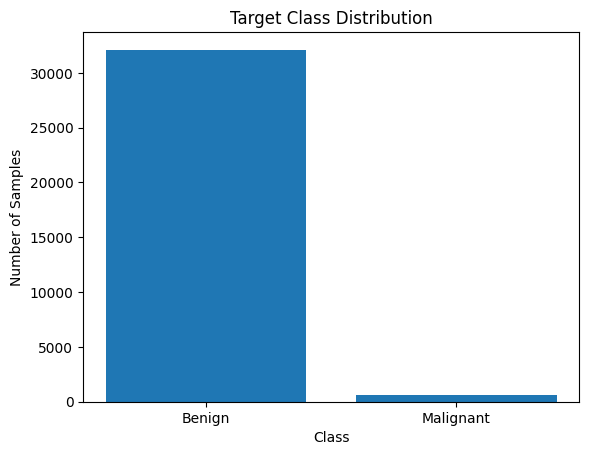

In [ ]:
#visualising the distribution of benign and malignant target values 
counts = cleanedGTV2_df["target"].value_counts().sort_index()
labels = ["Benign", "Malignant"]

plt.figure()
plt.bar(labels, counts)
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

As expected, the dataset is heavily imbalanced towards benign cases. This could leave the model to predominantly predicting the majority class while incorrectly identifying the rest, like other research papers suggest. This shows when creating the train and test splits, the target class needs split proportionally to maintain a similar ratio to prevent bias.

Next the diagnosis column will be visualised to check the distribution across the dataset 

In [ ]:
#Counting the total number of images for each listed diagnosis
diagnosisCount = cleanedGTV2_df["diagnosis"].value_counts()
print("Diagnosis distribution")
print(diagnosisCount)
print()

Diagnosis distribution
diagnosis
unknown                               26698
nevus                                  5191
melanoma                                581
seborrheic keratosis                    135
lentigo NOS                              44
lichenoid keratosis                      35
solar lentigo                             7
cafe-au-lait macule                       1
atypical melanocytic proliferation        1
Name: count, dtype: int64



The data from the diagnosis column shows that a large volume of images are unknown or in other words undiagnosed, this shows a large diagnosis imbalance which must be addressed in the train and test split during training. Out of the confirmed diagnosis, nevus appears the most at 5191 and melanoma second at 581, the rest appear at a lesser order of magnitude. As melanoma is the classification target for the model, a cross tabulation will be performed to confirm whether melanoma accounts for all malignant cases in the dataset.

In [ ]:
#Performing cross-tabulation against benign and malignant diagnosis
diagnosisBM = pd.crosstab(cleanedGTV2_df["diagnosis"], cleanedGTV2_df["benign_malignant"])
print("Diagnosis by benign/malignant")
print(diagnosisBM)

Diagnosis by benign/malignant
benign_malignant                    benign  malignant
diagnosis                                            
atypical melanocytic proliferation       1          0
cafe-au-lait macule                      1          0
lentigo NOS                             44          0
lichenoid keratosis                     35          0
melanoma                                 0        581
nevus                                 5191          0
seborrheic keratosis                   135          0
solar lentigo                            7          0
unknown                              26698          0


The results of the cross tabulation reveal that melanoma accounts for all malignant cases, with all others labeled benign. This shows that the classification task will focus on identifying melanoma over other benign conditions.
This is a significant finding, as it confirms that the malignant is directly aligned with the melanoma diagnosis within this dataset. As a result, the classification task can be clearly defined as determining whether a given lesion is melanoma or not.

Following on from this, insights may also be gained by grouping images by patient_id.

In [ ]:
#Analysing the data via patients_id along with distribution
patientCount = cleanedGTV2_df["patient_id"].value_counts()

print("Total unique patients")
print(patientCount.shape[0])
print("---")
print("Total images")
print(len(cleanedGTV2_df))

print("---")
print("Average images per patient")
print(f"{patientCount.mean():.1f}")

print("---")
print("Max images from one patient")
print(patientCount.max())

print("---")
print()
print("Distribution of images per patient")
print(patientCount.describe().round(1))

Total unique patients
2056
---
Total images
32693
---
Average images per patient
15.9
---
Max images from one patient
115
---

Distribution of images per patient
count    2056.0
mean       15.9
std        15.3
min         2.0
25%         5.0
50%        12.0
75%        22.0
max       115.0
Name: count, dtype: float64


The data shows that there are small number of unique patients when compared to the total amount of images in the dataset, of over 30000.
The average is rounded 16 images per patient with some having as little as 2 images, while other have a total of 115.
This data will be visualised to better understanding the significance.

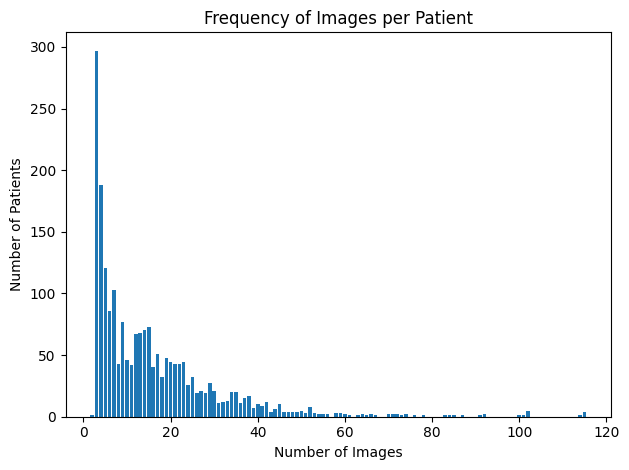

In [ ]:
#plotting the number of images per patient to visualise image distribution
frequency = patientCount.value_counts().sort_index()

plt.bar(frequency.index, frequency.values)
plt.title("Frequency of Images per Patient")
plt.xlabel("Number of Images")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

This frequency chart demonstrates that a small number of people within the dataset contribute a disproportionately high number of images, which may skew the dataset distribution. As the rounded average distribution is 16 images per patient and the dataset contains a total of 2056 unique patients, splitting the dataset based on the patients would be the logical choice to balance the image distribution. If a random split were performed instead this could lead to instances of bias and unfairness due to the model learning individual patients rather than melanoma itself.

Following this, cross tabulation will be performed using sex and benign_malignant to investigate if diagnosed cases vary by sex, along with anatom_site_general_challenge and benign_malignant to investigate if diagnosis cases vary by anatom_site_general_challenge

In [ ]:
#Performing cross-tabulation of benign and malignant cases by sex
comparisonSBM = pd.crosstab(cleanedGTV2_df["sex"], cleanedGTV2_df["benign_malignant"])
print("Comparison of sex and benign_malignant")
print(comparisonSBM)
print()

Comparison of sex and benign_malignant
benign_malignant  benign  malignant
sex                                
female             15566        218
male               16505        363
unknown               41          0



In [ ]:
#Performing cross-tabulation of benign and malignant cases by sex with normalisation
comparisonSBM = pd.crosstab(cleanedGTV2_df["sex"], cleanedGTV2_df["benign_malignant"], normalize='index')
malignantPercent = comparisonSBM["malignant"] * 100


print(malignantPercent.round(2))

sex
female     1.38
male       2.15
unknown    0.00
Name: malignant, dtype: float64


In [ ]:
#Calculating how likely males are to have a malignant diagnosis than females
maleRate = malignantPercent["male"]
femaleRate = malignantPercent["female"]
riskRatio = maleRate / femaleRate
ratioPercent = (riskRatio - 1) * 100
print("Percentage likelyhood of melignant diagnosis in men over women")
print(round(ratioPercent),"%")

Percentage likelyhood of melignant diagnosis in men over women
56 %


The data shows that males are 56% more likely to have a diagnosis than women, although a significant statistic, this warrants further investigation as this could be influenced by other factors like the sample demographic for this dataset. 

The following cross tabulation on anatom_site_general_challenge continues this investigation.

In [ ]:
#Performing cross-tabulation of benign and malignant cases by anatomical site
comparisonABM = pd.crosstab(cleanedGTV2_df["anatom_site_general_challenge"], cleanedGTV2_df["benign_malignant"])
print("Comparison of anatom_site_general_challenge and benign_malignant")
print(comparisonABM)
print()

Comparison of anatom_site_general_challenge and benign_malignant
benign_malignant               benign  malignant
anatom_site_general_challenge                   
head/neck                        1741         74
lower extremity                  8195        123
oral/genital                      120          4
palms/soles                       370          5
torso                           16375        257
unknown                           517          9
upper extremity                  4794        109



In [ ]:
#Performing cross-tabulation to calculate the percentage of malignant cases by anatomical site with normalisation
comparisonABM = pd.crosstab(cleanedGTV2_df["anatom_site_general_challenge"], cleanedGTV2_df["benign_malignant"], normalize='index')
malignantPercent = comparisonABM["malignant"] * 100


print(malignantPercent.round(2))

anatom_site_general_challenge
head/neck          4.08
lower extremity    1.48
oral/genital       3.23
palms/soles        1.33
torso              1.55
unknown            1.71
upper extremity    2.22
Name: malignant, dtype: float64


In [ ]:
#Identifying the lowest malignant rate as a baseline percentage
lowestRate = malignantPercent.min()
print("lowest rate of cancer is on on palms/soles at")
print(round(lowestRate, 2), "%")

lowest rate of cancer is on on palms/soles at
1.33 %


In [ ]:
#Calculating how much more likely each anatom_site is to be malignant compared to the lowestRate
riskRatioAll = malignantPercent / lowestRate
percentMoreLikelyAll = (riskRatioAll - 1) * 100

print(percentMoreLikelyAll.round(1))

anatom_site_general_challenge
head/neck          205.8
lower extremity     10.9
oral/genital       141.9
palms/soles          0.0
torso               15.9
unknown             28.3
upper extremity     66.7
Name: malignant, dtype: float64


Using palms/soles as a baseline due to its low malignancy rate, a risk ratio was calculated for the dataset. This shows how much more likely malignant cases appear on different parts the body. The head/neck and torso sections show the highest rate of melanoma, with the rate of oral/genital less so. This data shows that a larger portion of the people sampled have malignant cases on those sites over others, and as all malignant cases are melanoma, this would suggest that those sites are exposed more to the sun than others. Although, in the case of oral/genital, the label combines two distinct areas, making it difficult to draw specific conclusions from this category alone. This information could be useful for medical professionals as areas of focus when performing physical assessments. 

The distribution of benign and malignant diagnoses ages, may also provide some important information. This will be explored visually using a histogram.

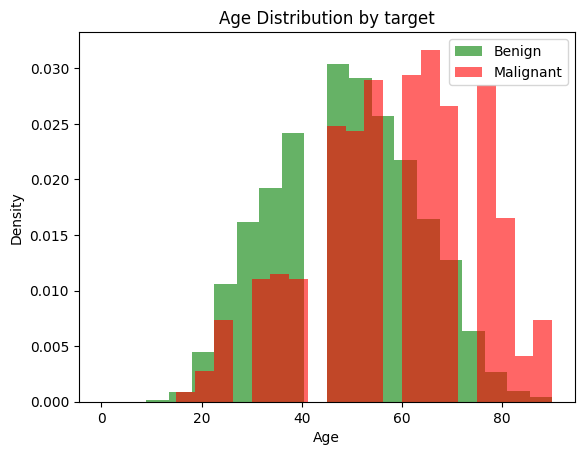

In [ ]:
#Plotting age distributions for benign and malignant cases using a histagram
benignAge = cleanedGTV2_df[cleanedGTV2_df["target"] == 0]["age_approx"]
malignantAge = cleanedGTV2_df[cleanedGTV2_df["target"] == 1]["age_approx"]

plt.hist(benignAge, bins=20, alpha=0.6, label="Benign", color="green", density=True)
plt.hist(malignantAge, bins=20, alpha=0.6, label="Malignant", color="red", density=True)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Age Distribution by target")
plt.legend()
plt.show()

This normalised histogram shows a clear difference in the age distribution between benign and malignant cases. The benign distribution is relatively spread across age groups although spikes at roughly age 50, while the malignant distribution is visibly shifted toward older ages with a higher concentration between 50 and 80. As the risk of melanoma is more likely to occur in people that have more exposure to the sun, this is also reflected in the people within the data in this dataset sample.

To better visualise this, the age data will be separated into groups and combined with the sex column in a pivot table. This will determine whether the rise in malignancy rate with increasing age is consistent for both males and females, or whether the overall trend is more heavily influenced by one sex than the other.


In [ ]:
#Counting number of cases by grouping into age ranges
ageGrouping = [0, 20, 40, 60, 80, 100]
ageLabels = ["0-20", "21-40", "41-60", "61-80", "81-100"]
ageSex_df = cleanedGTV2_df.copy()
ageSex_df["ageGroup"] = pd.cut(ageSex_df["age_approx"], bins=ageGrouping, labels=ageLabels)

ageSex_df["ageGroup"].value_counts().sort_index()

ageGroup
0-20        804
21-40     10217
41-60     15692
61-80      5749
81-100      229
Name: count, dtype: int64

All ages have been correctly grouped into selecteds age ranges.

In [ ]:
#Creating a pivot table to calculate the average malignant melanoma rate by age group and sex
ageSexTable = pd.pivot_table(ageSex_df, index="ageGroup", columns="sex", values="target", aggfunc="mean")
ageSexTable = (ageSexTable * 100).round(2)

print("The average rate of malignant melanoma grouped by age and sex")
print(ageSexTable)

The average rate of malignant melanoma grouped by age and sex
sex       female   male  unknown
ageGroup                        
0-20        1.28   0.73      NaN
21-40       0.64   1.16      NaN
41-60       1.27   1.70      0.0
61-80       3.21   4.34      NaN
81-100     10.32  11.65      NaN


The pivot table confirms that the rate rate of melanoma increases with age for both males and females. Males show a higher rate than females from the ages of 21-40 onwards, this validates the earlier finding that males are more likely to have a malignant diagnosis, than females. The 81-100 age group has the highest rates for both sexes at 10.32% for females and 11.65% for males. The 0-20 group is the only age range where females show a higher rate than males, although this could just be a reflection of the sample group. The column label unknown can be disregarded as it provides no meaningful information.

With anaysis finalised, the cleaned csv file will be saved for use in the training and testing stages of model training.

In [ ]:
#Saving the final cleaned dataset for use in model training and testing
cleanedGTV2_df.to_csv("../data/cleaned_csv/cleanedGroundTruth_V2.csv", index=False)
print("dataset saved")
print(cleanedGTV2_df.shape)

dataset saved
(32693, 9)


Summary of the Data

The three CSV files included in the ISIC 2020 dataset were loaded and examined: ISIC_2020_Training_GroundTruth, ISIC_2020_Training_GroundTruth_v2, and ISIC_2020_Training_Duplicates.
The ISIC_2020_Training_GroundTruth_v2 file was selected as the primary working dataset because it includes the lesion_id field, which is essential for identifying repeated samples alongside the duplicates file.
When comparing the duplicates file with the GroundTruth_v2 dataset, 425 duplicate image pairs were identified. These samples were manually inspected, verified, and removed. During further analysis, an additional eight duplicate lesion_id entries were discovered and removed after confirming that they represented identical images.

Further exploration revealed missing values within the dataset. These were addressed by replacing null entries in the sex and anatom_site_general_challenge columns with the string "unknown", and imputing missing age_approx values using the mean age of 49. After cleaning, the working dataset contained 32,693 unique lesion records.

Visualisation of the class distribution demonstrated that the dataset is highly imbalanced, with the majority of cases labelled as benign and only 581 classified as malignant. Importantly, all malignant cases correspond to melanoma. This confirms that the binary classification task is effectively distinguishing melanoma from benign lesions, which aligns with how the dataset is labelled and supports its selection for this project.

Grouping by patient_id revealed 2,056 unique patients contributing an average of 16 images each, with some patients providing as many as 115 images. This reinforces the need to perform dataset splitting across distinct patients in order to prevent the model from learning individual patient characteristics rather than melanoma-specific features. Additionally, variations in skin colour and other patient attributes could introduce further bias if alternative separation methods are used.

The analysis shows that males have approximately a 56% higher likelihood of malignant diagnosis compared to females. Anatomical site analysis indicates that lesions located on the head/neck and torso regions exhibit the highest malignancy rates. Additionally, malignancy rates increase with age, with the highest recorded frequency occurring between 50 and 80 years. Pivot table analysis combining age and sex demonstrates that this trend is present across both sexes, although males consistently show higher malignancy rates from age 21 onwards.

The cleaned dataset will be saved and used as the input for model training and testing, ensuring that all preprocessing steps are finalised before model development begins.

The insights gained from this analysis will directly inform the modelling strategy, particularly in addressing class imbalance, implementing data splitting across distinct patients, and ensuring that performance evaluation is conducted fairly across demographic groups.